In [1]:
import warnings
warnings.filterwarnings("ignore")
import time
from pathlib import Path
import random

from src.model import (
    load_data, explore_data, split_data, EDA, data_cleaning,
    encode_data, select_model, compare_ensembles,
    tune_hyperparameters, important_features, evaluate_model
)

In [2]:
seed = random.randint(1000, 9999)
print("Random seed: ", seed)

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "term-deposit-marketing-2020.csv"

Random seed:  3174


       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
39995   53    technician   married   tertiary      no      395      no   no   
39996   30    management    single   tertiary      no     3340      no   no   
39997   54         admin  divorced  secondary      no      200      no   no   
39998   34    management   married   tertiary      no     1047      no   no   
39999   38    technician   married  secondary      no     1442     yes   no   

        contact  day month  duration  campaign    y  
0       unknown    5   may       261         1   no  
1       unknown    5  

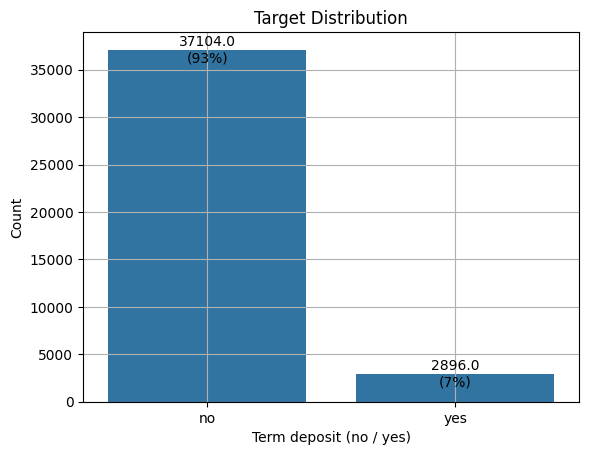

In [3]:
term_deposit_df = load_data(DATA_PATH)
numeric_df, categorical_df = explore_data(term_deposit_df)

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    term_deposit_df, target="y", seed=seed
)

Size of the training set: 24000
Size of the validation set: 12800
Size of the testing set: 3200



Categorical Value Counts (Train + Val)

job
blue-collar      8683
management       7505
technician       6262
admin            4110
services         3592
self-employed    1327
retired          1319
entrepreneur     1284
unemployed       1022
housemaid         993
student           487
unknown           216
 
marital
married     22448
single      10017
divorced     4335
 
education
secondary    19326
tertiary     10282
primary       5798
unknown       1394
 
default
no     36056
yes      744
 
housing
yes    22120
no     14680
 
loan
no     30422
yes     6378
 
contact
cellular     22957
unknown      11712
telephone     2131
 
month
may    12449
jul     5874
aug     4804
jun     4351
nov     3325
apr     2501
feb     2112
jan     1073
mar      229
oct       71
dec       11
 
y
no     34136
yes     2664
 


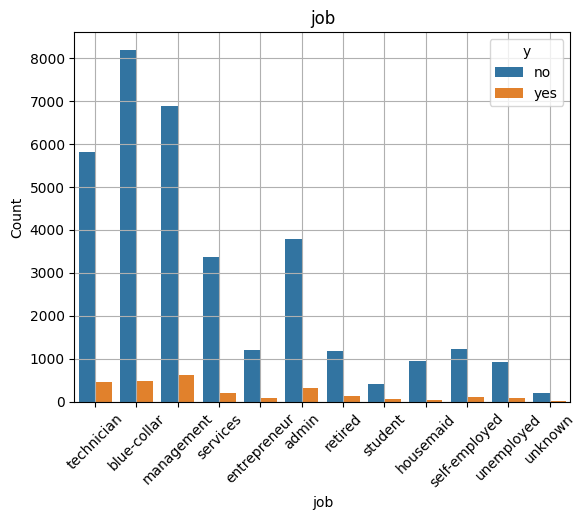

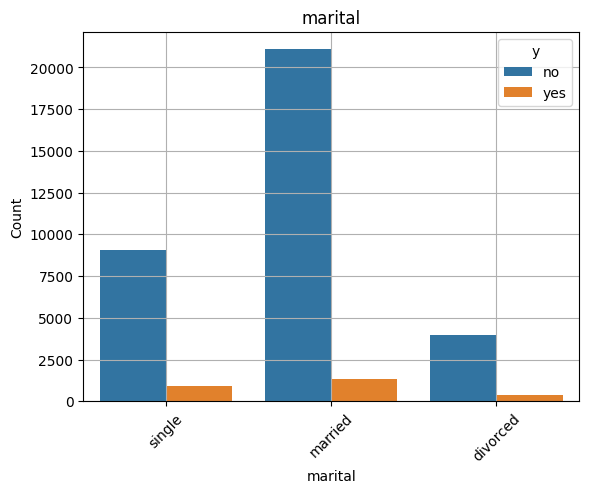

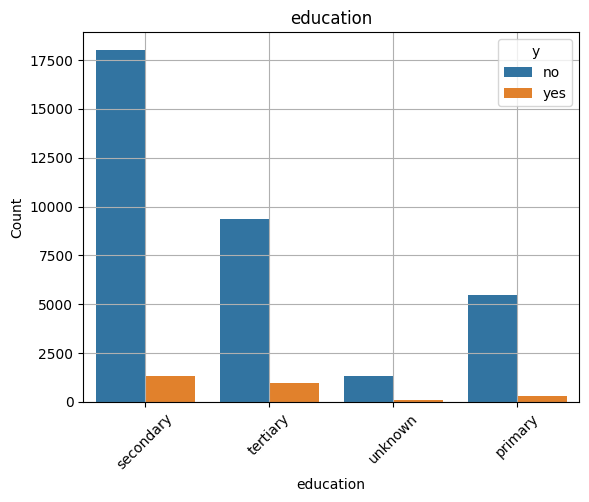

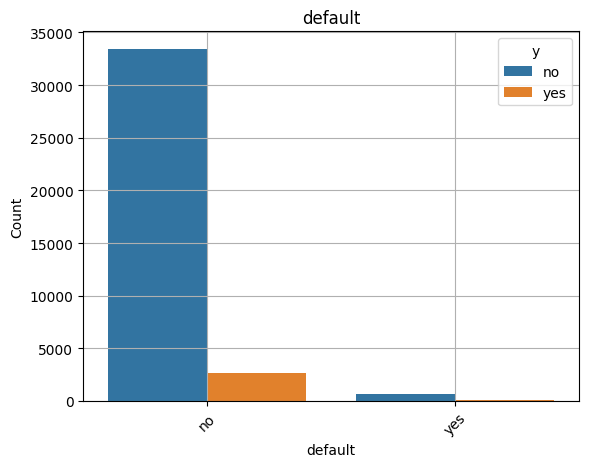

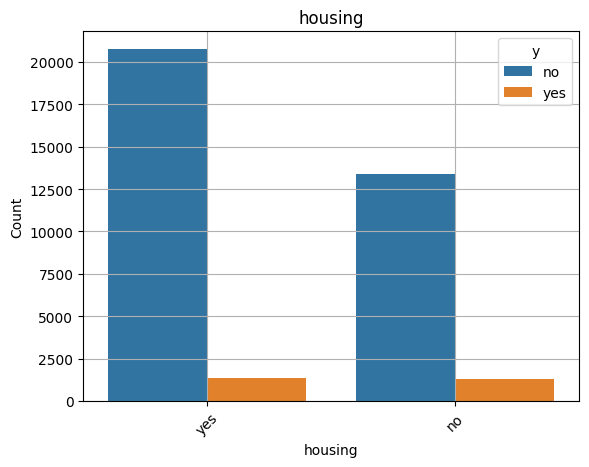

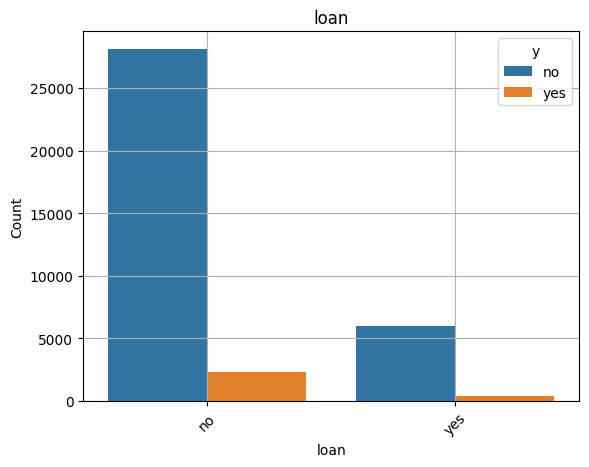

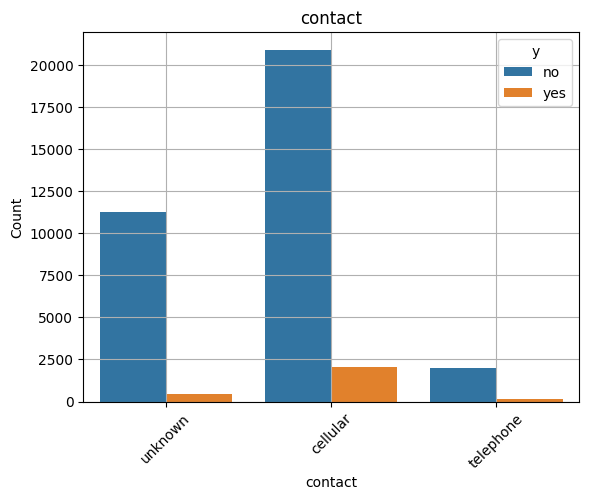

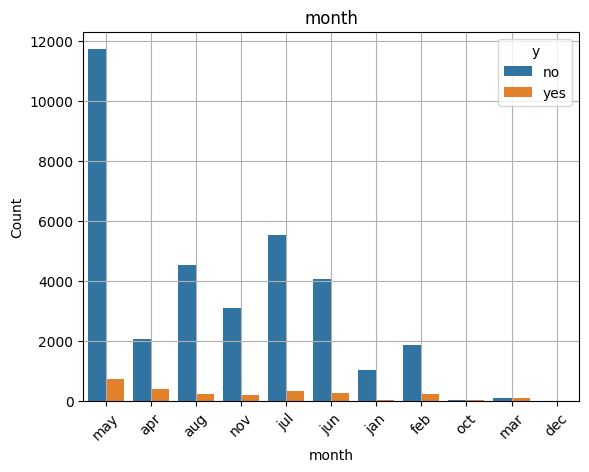

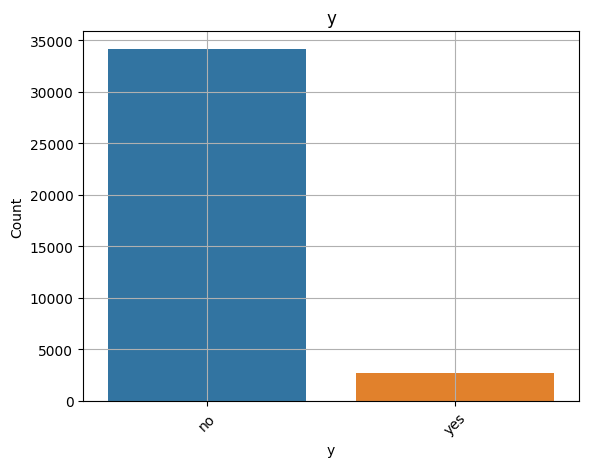

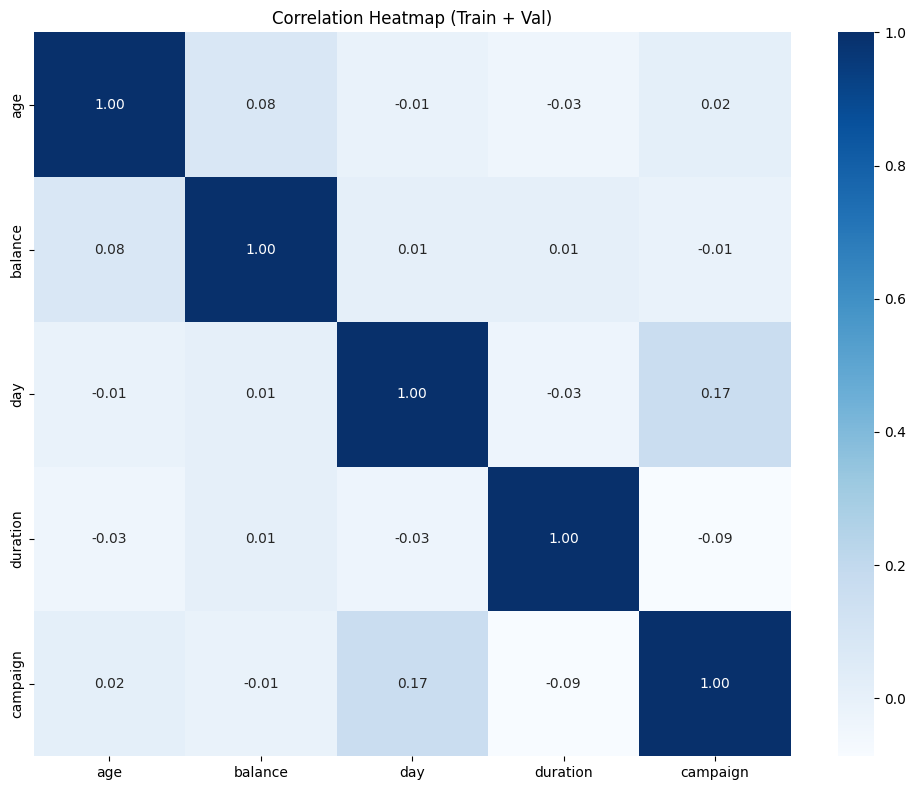

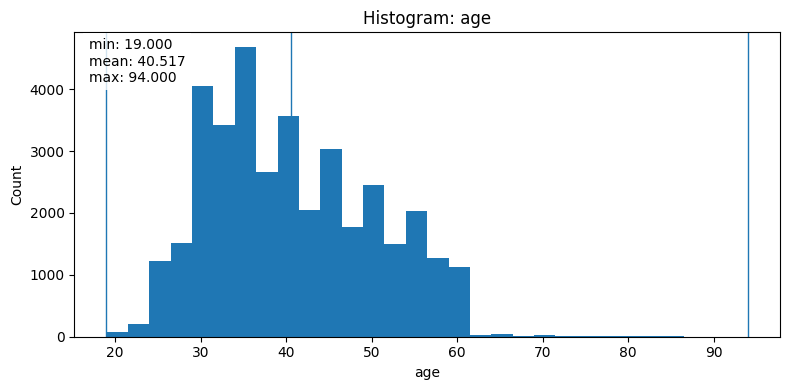

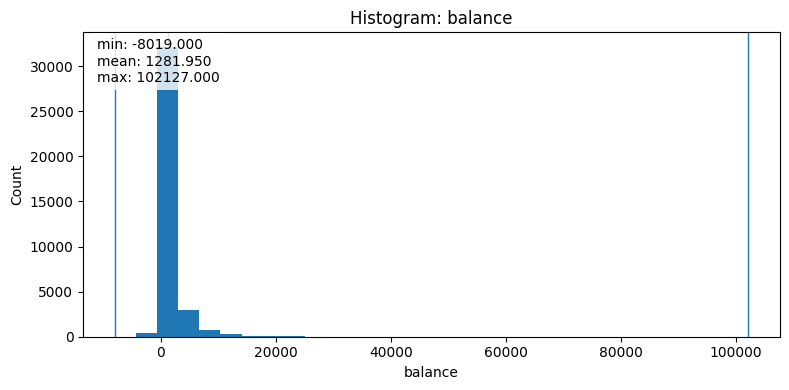

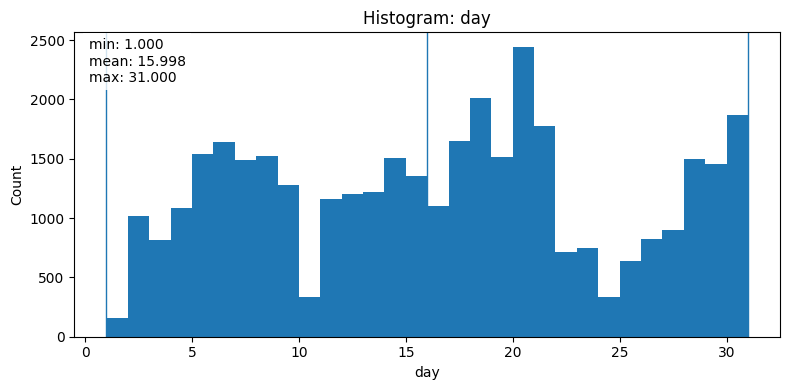

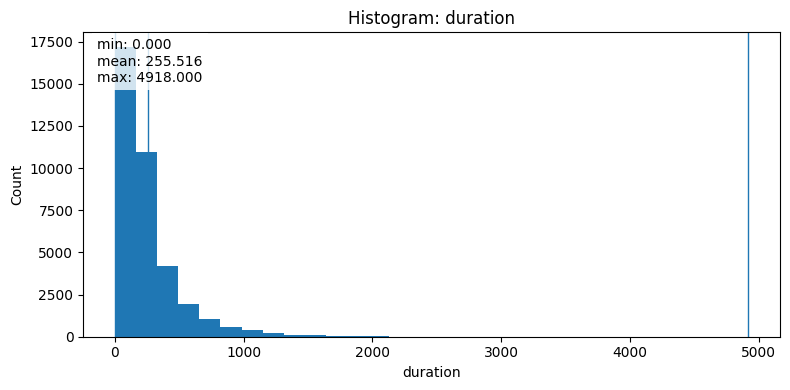

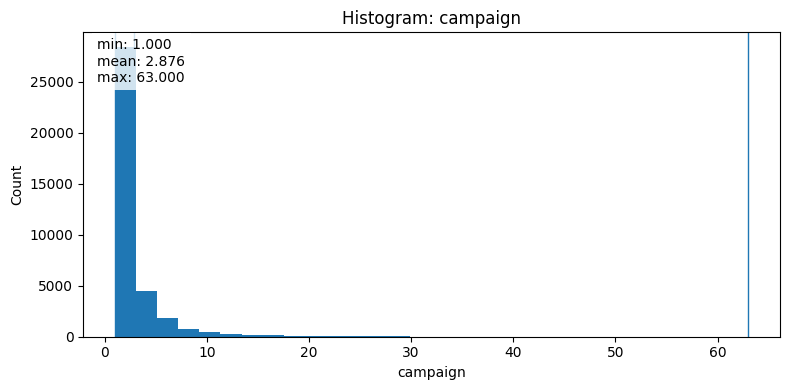

In [5]:
df_tv = EDA(X_train, y_train, X_val, y_val, categorical_df, numeric_df)

In [6]:
term_deposit_df, cat_mode, num_bounds = data_cleaning(
    df_tv, categorical_df, numeric_df
)

In [7]:
X_train, X_val, y_train, y_val, le_dict, scaler, le_y = encode_data(
    X_train, X_val, y_train, y_val, categorical_df, numeric_df
)

In [8]:
start_select = time.time()
models, predictions = select_model(X_train, X_val, y_train, y_val)
end_select = time.time()
print(models)
print(f"\nselect_model duration: {end_select - start_select:.2f} seconds")

  0%|          | 0/31 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 1738, number of negative: 22262
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.072417 -> initscore=-2.550146
[LightGBM] [Info] Start training from score -2.550146

Best model for minority class: NearestCentroid
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.88               0.80     0.80      0.90   
Perceptron                         0.91               0.73     0.73      0.91   
PassiveAggressiveClassifier        0.89               0.72     0.72     

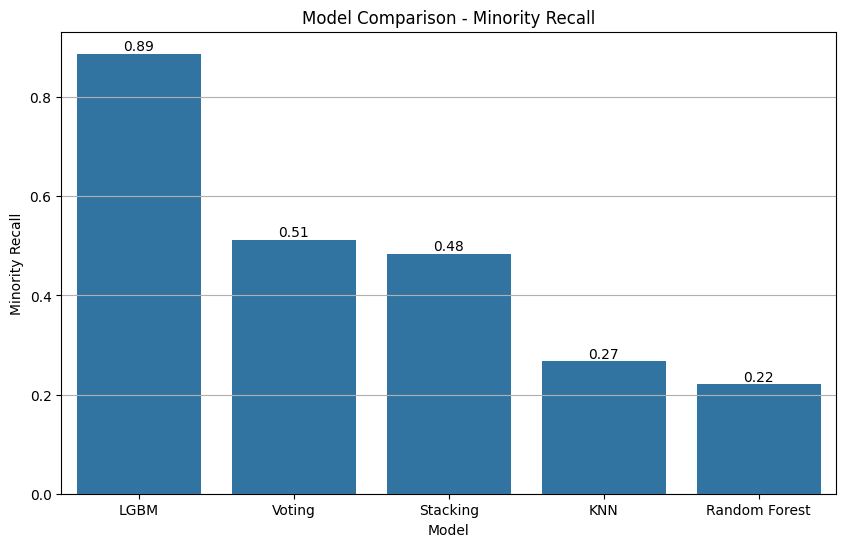


compare_ensembles duration: 94.00 seconds
           Model  Minority_Recall
2           LGBM             0.89
3         Voting             0.51
4       Stacking             0.48
0            KNN             0.27
1  Random Forest             0.22


In [9]:
start_ensemble = time.time()
fitted_models, results_df = compare_ensembles(
    X_train, y_train, X_val, y_val, seed, cv=5
)
end_ensemble = time.time()
print(f"\ncompare_ensembles duration: {end_ensemble - start_ensemble:.2f} seconds")
print(results_df)

In [10]:
best_model, best_params, best_score = tune_hyperparameters(
    X_train, y_train, X_val, y_val, seed
)

100%|██████████| 20/20 [00:09<00:00,  2.21trial/s, best loss: -0.9016516516516516]
Best Parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': np.float64(0.06796626309459171), 'num_leaves': 15, 'min_child_samples': 20, 'subsample': np.float64(0.8954092667054943), 'colsample_bytree': np.float64(0.8557484120488831)}
Best Score: 0.9


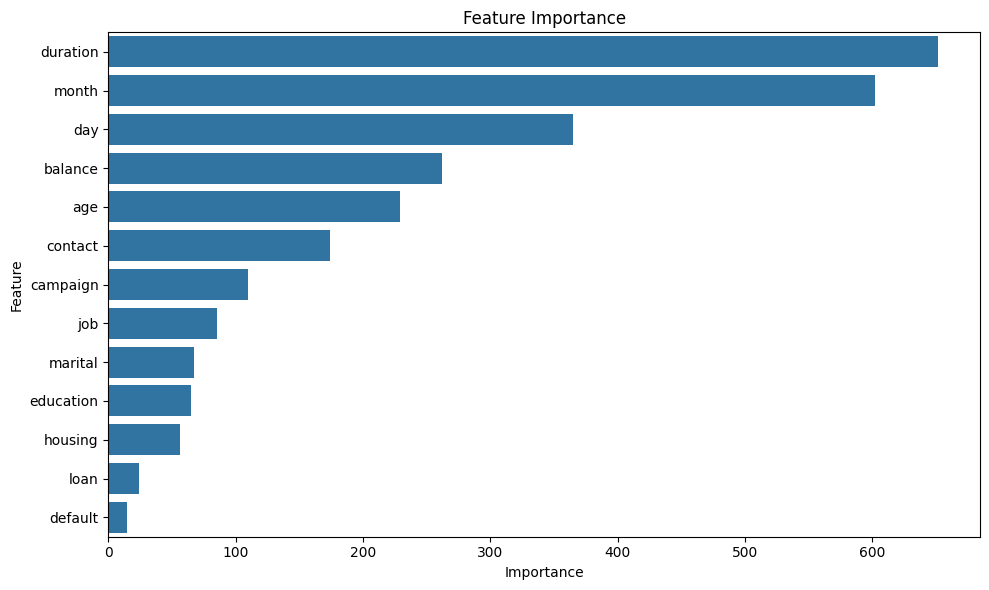

      Feature  Importance
0    duration         652
1       month         602
2         day         365
3     balance         262
4         age         229
5     contact         174
6    campaign         110
7         job          85
8     marital          67
9   education          65
10    housing          56
11       loan          24
12    default          15


In [11]:
feature_df = important_features(X_train, best_model)
print(feature_df)

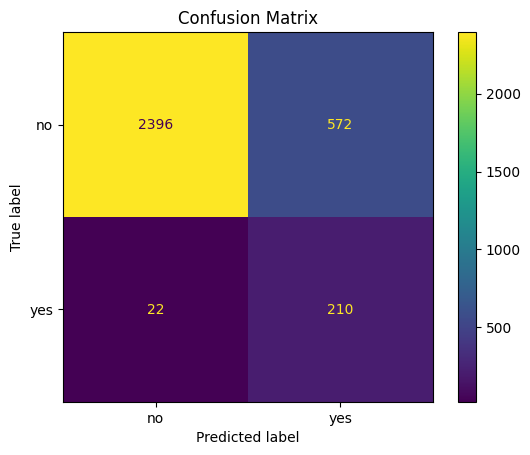

              precision    recall  f1-score   support

          no       0.99      0.81      0.89      2968
         yes       0.27      0.91      0.41       232

    accuracy                           0.81      3200
   macro avg       0.63      0.86      0.65      3200
weighted avg       0.94      0.81      0.86      3200



In [12]:
clf_report = evaluate_model(
    best_model, X_test, y_test,
    categorical_df, numeric_df,
    cat_mode, num_bounds, le_dict, scaler, le_y
)
print(clf_report)